In [2]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import os
DATA_DIR = Path("/content/drive/MyDrive/STATS201_project/torres_replication/")
CAPSULE_DATA = DATA_DIR / "capsule" / "data"
IMAGES_DIR = CAPSULE_DATA / "Images2"

print("DATA_DIR exists:", DATA_DIR.exists())
print("CAPSULE_DATA exists:", CAPSULE_DATA.exists())
print("IMAGES_DIR exists:", IMAGES_DIR.exists())

meta_path = CAPSULE_DATA / "metadata_caravan_media_short.csv"
clusters_path = CAPSULE_DATA / "clusters_preds_caravan_newsapi.csv"

print("meta_path exists:", meta_path.exists())
print("clusters_path exists:", clusters_path.exists())
print("Exists:", os.path.exists(DATA_DIR))
print("Top-level items:", os.listdir(DATA_DIR)[:30])


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_DIR exists: True
CAPSULE_DATA exists: True
IMAGES_DIR exists: True
meta_path exists: True
clusters_path exists: True
Exists: True
Top-level items: ['capsule', 'result', 'df_with_face_features.csv']


In [8]:
meta = pd.read_csv(meta_path, encoding="latin1")
clusters = pd.read_csv(clusters_path)

In [3]:

def tree(root, max_depth=4, max_files=500):
    root = Path(root)
    n = 0
    for p in sorted(root.rglob("*")):
        rel = p.relative_to(root)
        if len(rel.parts) <= max_depth:
            if p.is_dir():
                print(f"[DIR ] {rel}")
            else:
                size_mb = p.stat().st_size / (1024**2)
                print(f"[FILE] {rel}  ({size_mb:.2f} MB)")
                n += 1
                if n >= max_files:
                    print(f"...stopped after {max_files} files")
                    break

tree(DATA_DIR, max_depth=4)


[DIR ] capsule
[FILE] capsule/.gitignore  (0.00 MB)
[FILE] capsule/REPRODUCING.md  (0.00 MB)
[DIR ] capsule/code
[FILE] capsule/code/00_Fig01.py  (0.00 MB)
[FILE] capsule/code/01_index_features.py  (0.01 MB)
[FILE] capsule/code/02_testncluster_features.py  (0.00 MB)
[FILE] capsule/code/03_match_features_images.R  (0.00 MB)
[FILE] capsule/code/04_visualize_centers.py  (0.00 MB)
[FILE] capsule/code/05_extract_bovw.py  (0.00 MB)
[FILE] capsule/code/06_STM_CreateObjects.R  (0.00 MB)
[FILE] capsule/code/07_CreateFigures_Main.R  (0.01 MB)
[FILE] capsule/code/08_Appendix.R  (0.03 MB)
[FILE] capsule/code/08_FigureA10.py  (0.00 MB)
[FILE] capsule/code/Functions2ProcessIVW.R  (0.01 MB)
[FILE] capsule/code/LICENSE  (0.01 MB)
[FILE] capsule/code/ReadMe.pdf  (0.12 MB)
[FILE] capsule/code/TEST2.py  (0.00 MB)
[FILE] capsule/code/run  (0.01 MB)
[FILE] capsule/code/test.R  (0.00 MB)
[DIR ] capsule/data
[FILE] capsule/data/Coder01.csv  (0.00 MB)
[FILE] capsule/data/Coder02.csv  (0.00 MB)
[FILE] capsule/

In [4]:

root = Path(DATA_DIR)

def list_by_ext(exts, max_show=80):
    exts = tuple(exts)
    matches = sorted([p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in exts])
    print(f"Found {len(matches)} files with extensions {exts}")
    for p in matches[:max_show]:
        print(" -", p.relative_to(root))
    if len(matches) > max_show:
        print(f"... (+{len(matches)-max_show} more)")
    return matches

csvs  = list_by_ext([".csv"])
hdf5s = list_by_ext([".h5", ".hdf5"])
pys   = list_by_ext([".py"])
ipynb = list_by_ext([".ipynb"])
imgs  = list_by_ext([".png", ".jpg", ".jpeg", ".webp"])


Found 18 files with extensions ('.csv',)
 - capsule/data/Coder01.csv
 - capsule/data/Coder02.csv
 - capsule/data/Coder03.csv
 - capsule/data/clusters_preds_caravan_newsapi.csv
 - capsule/data/metadata_caravan_media_short.csv
 - df_with_face_features.csv
 - result/HT0300/wss_by_k.csv
 - result/HT1000/wss_by_k.csv
 - result/HT2000/wss_by_k.csv
 - result/HT3000/wss_by_k.csv
 - result/indexMedia.csv
 - result/sample_index.csv
 - result/sample_index_ht0300.csv
 - result/sample_index_ht1000.csv
 - result/sample_index_ht2000.csv
 - result/sample_index_ht3000.csv
 - result/sample_index_rev.csv
 - result/wss_by_k.csv
Found 28 files with extensions ('.h5', '.hdf5')
 - capsule/data/caravan_getty_featuresDB.hdf5
 - capsule/data/caravan_getty_featuresDB_ht0300.hdf5
 - capsule/data/caravan_getty_featuresDB_ht2000.hdf5
 - capsule/data/caravan_getty_featuresDB_ht3000.hdf5
 - result/HT0300/caravan_media_IDF_2000.hdf5
 - result/HT0300/caravan_media_IDF_500.hdf5
 - result/HT0300/caravan_media_IDF_5000.hd

In [5]:
def find_files(keyword, max_show=50):
    keyword = keyword.lower()
    matches = sorted([p for p in root.rglob("*") if p.is_file() and keyword in p.name.lower()])
    print(f"Matches for '{keyword}':", len(matches))
    for p in matches[:max_show]:
        size_mb = p.stat().st_size / (1024**2)
        print(f"{size_mb:7.2f} MB  {p.relative_to(root)}")
    if len(matches) > max_show:
        print(f"... (+{len(matches)-max_show} more)")
    return matches

find_files("metadata")
find_files("clusters")
find_files("features")
find_files("caravan")
find_files("ReadMe")


Matches for 'metadata': 3
   0.28 MB  capsule/data/metadata_caravan_media_short.csv
   0.00 MB  capsule/data/metadata_caravan_media_short.gsheet
   0.00 MB  capsule/metadata/metadata.yml
Matches for 'clusters': 1
   0.01 MB  capsule/data/clusters_preds_caravan_newsapi.csv
Matches for 'features': 12
   0.01 MB  capsule/code/01_index_features.py
   0.00 MB  capsule/code/02_testncluster_features.py
   0.00 MB  capsule/code/03_match_features_images.R
1632.37 MB  capsule/data/caravan_getty_featuresDB.hdf5
2540.04 MB  capsule/data/caravan_getty_featuresDB_ht0300.hdf5
1094.07 MB  capsule/data/caravan_getty_featuresDB_ht2000.hdf5
 820.57 MB  capsule/data/caravan_getty_featuresDB_ht3000.hdf5
   0.26 MB  df_with_face_features.csv
 160.76 MB  result/caravan_media_featuresDB.hdf5
 251.86 MB  result/caravan_media_featuresDB_ht0300.hdf5
 107.40 MB  result/caravan_media_featuresDB_ht2000.hdf5
  79.43 MB  result/caravan_media_featuresDB_ht3000.hdf5
Matches for 'caravan': 31
1632.37 MB  capsule/data/ca

[PosixPath('/content/drive/MyDrive/STATS201_project/torres_replication/capsule/code/ReadMe.pdf')]

In [6]:
def tree(path, max_depth=5, max_files=300):
    path = Path(path)
    root = path
    n = 0
    for p in sorted(root.rglob("*")):
        rel = p.relative_to(root)
        if len(rel.parts) <= max_depth:
            if p.is_dir():
                print(f"[DIR ] {rel}")
            else:
                size_mb = p.stat().st_size / (1024**2)
                print(f"[FILE] {rel} ({size_mb:.2f} MB)")
                n += 1
                if n >= max_files:
                    print(f"...stopped after {max_files} files")
                    break

capsule_dir = root / "capsule"
result_dir  = root / "result"

print("=== capsule/ tree ===")
tree(capsule_dir, max_depth=4)

print("\n=== result/ tree ===")
tree(result_dir, max_depth=4)


=== capsule/ tree ===
[FILE] .gitignore (0.00 MB)
[FILE] REPRODUCING.md (0.00 MB)
[DIR ] code
[FILE] code/00_Fig01.py (0.00 MB)
[FILE] code/01_index_features.py (0.01 MB)
[FILE] code/02_testncluster_features.py (0.00 MB)
[FILE] code/03_match_features_images.R (0.00 MB)
[FILE] code/04_visualize_centers.py (0.00 MB)
[FILE] code/05_extract_bovw.py (0.00 MB)
[FILE] code/06_STM_CreateObjects.R (0.00 MB)
[FILE] code/07_CreateFigures_Main.R (0.01 MB)
[FILE] code/08_Appendix.R (0.03 MB)
[FILE] code/08_FigureA10.py (0.00 MB)
[FILE] code/Functions2ProcessIVW.R (0.01 MB)
[FILE] code/LICENSE (0.01 MB)
[FILE] code/ReadMe.pdf (0.12 MB)
[FILE] code/TEST2.py (0.00 MB)
[FILE] code/run (0.01 MB)
[FILE] code/test.R (0.00 MB)
[DIR ] data
[FILE] data/Coder01.csv (0.00 MB)
[FILE] data/Coder02.csv (0.00 MB)
[FILE] data/Coder03.csv (0.00 MB)
[DIR ] data/Images2
[FILE] data/Images2/abc-news_0000_11.jpg (0.04 MB)
[FILE] data/Images2/abc-news_0001_1.jpg (0.09 MB)
[FILE] data/Images2/abc-news_0002_1.jpg (0.08 MB)

In [9]:
import pandas as pd

clusters_df = clusters
print("clusters_df:", clusters_df.shape)
clusters_df.head()


clusters_df: (517, 2)


,file,predicted_labels
0,abc-news_0000_11.jpg.p,3
1,abc-news_0001_1.jpg.p,7
2,abc-news_0002_1.jpg.p,6
3,abc-news_0003_2.jpg.p,5
4,abc-news_0003_3.jpg.p,8


In [34]:
print(meta.shape, clusters.shape)
meta.head(2), clusters.head(2)

(688, 15) (517, 2)


(                imageid      articleid          domain screen_name2  \
 0  abc-news_0000_11.jpg  abc-news_0000  abcnews.go.com          abc   
 1   abc-news_0001_1.jpg  abc-news_0001  abcnews.go.com          abc   
 
   newspapername newspaperid                   author  \
 0      ABC News    abc-news              b'ABC News'   
 1      ABC News    abc-news  b'The Associated Press'   
 
                                                title  \
 0  b"WATCH: President Trump calls caravan migrant...   
 1  b'56,800 dead and missing: The hidden toll of ...   
 
                                          description                     date  \
 0  b'In an exclusive interview with ABC News Trum...  b'2018-11-01T17:05:40Z'   
 1  b"An Associated Press tally has documented mor...  b'2018-11-01T16:22:37Z'   
 
   ideol_allsides  iscrowd  istrump    date2  topicality  
 0    left-center        0        1  11/1/18         0.0  
 1    left-center        0        0  11/1/18         0.0  ,
          

In [11]:
# clusters file has: file, predicted_labels
# meta file has: imageid, iscrowd

clusters["imageid"] = clusters["file"].astype(str).str.replace(r"\.p$", "", regex=True)

df = meta.merge(clusters[["imageid", "predicted_labels"]], on="imageid", how="inner")

df["y"] = df["iscrowd"].astype(int)
X = df[["predicted_labels"]]   # same baseline feature
y = df["y"]

print("Merged df:", df.shape)
print(y.value_counts(normalize=True))
df[["imageid","predicted_labels","y"]].head()


Merged df: (517, 17)
y
0    0.789168
1    0.210832
Name: proportion, dtype: float64


,imageid,predicted_labels,y
0,abc-news_0000_11.jpg,3,0
1,abc-news_0001_1.jpg,7,0
2,abc-news_0002_1.jpg,6,0
3,abc-news_0003_2.jpg,5,0
4,abc-news_0003_3.jpg,8,0


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,      # 70/30 split
    random_state=42,
    stratify=y
)

print("train:", y_train.value_counts(normalize=True).to_dict())
print("test :", y_test.value_counts(normalize=True).to_dict())


train: {0: 0.7894736842105263, 1: 0.21052631578947367}
test : {0: 0.7884615384615384, 1: 0.21153846153846154}


In [13]:
print("num unique clusters:", df["predicted_labels"].nunique())
print(df["predicted_labels"].value_counts().head(10))

num unique clusters: 15
predicted_labels
7     75
3     59
10    43
1     41
0     40
2     39
5     37
14    36
6     35
8     34
Name: count, dtype: int64


In [14]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

maj = y_train.value_counts().idxmax()
y_pred_maj = np.full_like(y_test, maj)

print("Majority label:", maj)
print("Accuracy:", accuracy_score(y_test, y_pred_maj))
print(confusion_matrix(y_test, y_pred_maj))
print(classification_report(y_test, y_pred_maj, digits=3))

Majority label: 0
Accuracy: 0.7884615384615384
[[123   0]
 [ 33   0]]
              precision    recall  f1-score   support

           0      0.788     1.000     0.882       123
           1      0.000     0.000     0.000        33

    accuracy                          0.788       156
   macro avg      0.394     0.500     0.441       156
weighted avg      0.622     0.788     0.695       156



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("oh", OneHotEncoder(handle_unknown="ignore")),
    ("logit", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))


Accuracy: 0.8717948717948718
[[110  13]
 [  7  26]]
              precision    recall  f1-score   support

           0      0.940     0.894     0.917       123
           1      0.667     0.788     0.722        33

    accuracy                          0.872       156
   macro avg      0.803     0.841     0.819       156
weighted avg      0.882     0.872     0.876       156



In [16]:
X2 = df[["predicted_labels", "newspaperid", "ideol_allsides", "topicality"]].copy()

print(X2.isna().sum())
print("\nRows with any NaN:", X2.isna().any(axis=1).sum())
X2[X2.isna().any(axis=1)].head()

predicted_labels     0
newspaperid          0
ideol_allsides       0
topicality          59
dtype: int64

Rows with any NaN: 59


,predicted_labels,newspaperid,ideol_allsides,topicality
21,5,abc-news,left-center,NaN
22,5,abc-news,left-center,NaN
24,11,abc-news,left-center,NaN
25,2,abc-news,left-center,NaN
27,0,al-jazeera-english,center,NaN


In [17]:
mask = X2.notna().all(axis=1)
X2_clean = X2[mask]
y_clean  = y[mask]

print("Before:", X2.shape, "After:", X2_clean.shape)


Before: (517, 4) After: (458, 4)


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

cat_cols = ["predicted_labels", "newspaperid", "ideol_allsides"]
num_cols = ["topicality"]

pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols),
])

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_clean, y_clean, test_size=0.30, random_state=42, stratify=y_clean
)

model = Pipeline([
    ("pre", pre),
    ("logit", LogisticRegression(max_iter=4000, class_weight="balanced"))
])

model.fit(X2_train, y2_train)
pred2 = model.predict(X2_test)

print("Accuracy:", accuracy_score(y2_test, pred2))
print(confusion_matrix(y2_test, pred2))
print(classification_report(y2_test, pred2, digits=3))


Accuracy: 0.8623188405797102
[[97 12]
 [ 7 22]]
              precision    recall  f1-score   support

           0      0.933     0.890     0.911       109
           1      0.647     0.759     0.698        29

    accuracy                          0.862       138
   macro avg      0.790     0.824     0.805       138
weighted avg      0.873     0.862     0.866       138



In [19]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix

def summarize(name, y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[0,1])
    return {
        "model": name,
        "acc": accuracy_score(y_true, y_pred),
        "p1": p[1], "r1": r[1], "f1_1": f1[1],
        "cm": confusion_matrix(y_true, y_pred)
    }


In [20]:
results = []
results.append(summarize("Majority", y_test, y_pred_maj))
results.append(summarize("LogReg cluster", y_test, y_pred))
results.append(summarize("LogReg cluster+meta (dropna)", y2_test, pred2))

pd.DataFrame([{k:v for k,v in r.items() if k!="cm"} for r in results])


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,model,acc,p1,r1,f1_1
0,Majority,0.788462,0.000000,0.000000,0.000000
1,LogReg cluster,0.871795,0.666667,0.787879,0.722222
2,LogReg cluster+meta (dropna),0.862319,0.647059,0.758621,0.698413


In [21]:
for r in results:
    print(r["model"])
    print(r["cm"], "\n")


Majority
[[123   0]
 [ 33   0]] 

LogReg cluster
[[110  13]
 [  7  26]] 

LogReg cluster+meta (dropna)
[[97 12]
 [ 7 22]] 



In [22]:
# X with all rows
X2_2 = df[["predicted_labels", "newspaperid", "ideol_allsides", "topicality"]].copy()

# fill topicality NaN using median (so NO rows dropped)
X2_2["topicality"] = X2_2["topicality"].fillna(X2_2["topicality"].median())

# y with same rows
y2_2 = df["y"].astype(int)

cat_cols = ["predicted_labels", "newspaperid", "ideol_allsides"]
num_cols = ["topicality"]

pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols),
])

X2_2_train, X2_2_test, y2_2_train, y2_2_test = train_test_split(
    X2_2, y2_2,
    test_size=0.30, random_state=42, stratify=y2_2
)

model = Pipeline([
    ("pre", pre),
    ("logit", LogisticRegression(max_iter=4000, class_weight="balanced"))
])

model.fit(X2_2_train, y2_2_train)
pred2_2 = model.predict(X2_2_test)

print("Accuracy:", accuracy_score(y2_2_test, pred2_2))
print(confusion_matrix(y2_2_test, pred2_2))
print(classification_report(y2_2_test, pred2_2, digits=3))

Accuracy: 0.8717948717948718
[[108  15]
 [  5  28]]
              precision    recall  f1-score   support

           0      0.956     0.878     0.915       123
           1      0.651     0.848     0.737        33

    accuracy                          0.872       156
   macro avg      0.803     0.863     0.826       156
weighted avg      0.891     0.872     0.878       156



In [23]:
from sklearn.metrics import precision_recall_fscore_support
def summarize(y_true, y_pred, name):
    """
    Creates a single-row summary (accuracy + class-1 precision/recall/F1 + confusion matrix parts).
    Focus on class 1 (iscrowd=1) because it's usually the minority class.
    """
    acc = accuracy_score(y_true, y_pred)

    p, r, f, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1], zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    return {
        "model": name,
        "n_test": len(y_true),
        "acc": acc,
        "prec_1": p[1],
        "rec_1": r[1],
        "f1_1": f[1],
        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1]),
    }


In [24]:
# 2) Build results array
results = []

results.append(summarize(y_test,   y_pred_maj, "Majority (70/30)"))
results.append(summarize(y_test,   y_pred,  "LogReg cluster-only (70/30)"))

# Only append dropna if you actually have its prediction stored
if "pred2" in globals():
    results.append(summarize(y2_test, pred2, "LogReg cluster+meta (dropna) (70/30)"))
else:
    print("Skipping dropna model: `pred2` not found (it was overwritten by `pred`).")

results.append(summarize(y2_2_test, pred2_2, "LogReg cluster+meta (median-impute) (70/30)"))

# 3) Show a clean table
results_df = pd.DataFrame(results).sort_values("f1_1", ascending=False).reset_index(drop=True)
results_df

,model,n_test,acc,prec_1,rec_1,f1_1,tn,fp,fn,tp
0,LogReg cluster+meta (median-impute) (70/30),156,0.871795,0.651163,0.848485,0.736842,108,15,5,28
1,LogReg cluster-only (70/30),156,0.871795,0.666667,0.787879,0.722222,110,13,7,26
2,LogReg cluster+meta (dropna) (70/30),138,0.862319,0.647059,0.758621,0.698413,97,12,7,22
3,Majority (70/30),156,0.788462,0.000000,0.000000,0.000000,123,0,33,0


In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Reuse the SAME split you used for the imputed model so results are comparable:
# X2_2_train, X2_2_test, y2_2_train, y2_2_test
# Reuse the SAME preprocessor:
# pre

# 1) Decision Tree
tree_model = Pipeline([
    ("pre", pre),
    ("tree", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
        max_depth=6   # small depth to avoid overfitting; we can tune later
    ))
])

tree_model.fit(X2_2_train, y2_2_train)
tree_pred = tree_model.predict(X2_2_test)

results.append(summarize(y2_2_test, tree_pred, "DecisionTree (imputed) (70/30)"))

# 2) Random Forest
rf_model = Pipeline([
    ("pre", pre),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model.fit(X2_2_train, y2_2_train)
rf_pred = rf_model.predict(X2_2_test)

results.append(summarize(y2_2_test, rf_pred, "RandomForest (imputed) (70/30)"))

# Refresh table
results_df = pd.DataFrame(results).sort_values("f1_1", ascending=False).reset_index(drop=True)
results_df


,model,n_test,acc,prec_1,rec_1,f1_1,tn,fp,fn,tp
0,RandomForest (imputed) (70/30),156,0.910256,0.771429,0.818182,0.794118,115,8,6,27
1,LogReg cluster+meta (median-impute) (70/30),156,0.871795,0.651163,0.848485,0.736842,108,15,5,28
2,DecisionTree (imputed) (70/30),156,0.865385,0.636364,0.848485,0.727273,107,16,5,28
3,LogReg cluster-only (70/30),156,0.871795,0.666667,0.787879,0.722222,110,13,7,26
4,LogReg cluster+meta (dropna) (70/30),138,0.862319,0.647059,0.758621,0.698413,97,12,7,22
5,Majority (70/30),156,0.788462,0.000000,0.000000,0.000000,123,0,33,0


In [26]:

from sklearn.metrics import f1_score

# Assuming your imputed logistic pipeline is named `model` (from your imputed section)
# and your split is X2_2_test / y2_2_test
proba1 = model.predict_proba(X2_2_test)[:, 1]

best = {"thr": None, "f1_1": -1}
for thr in np.linspace(0.1, 0.9, 17):  # quick grid
    pred_thr = (proba1 >= thr).astype(int)
    f1_1 = f1_score(y2_2_test, pred_thr, pos_label=1)
    if f1_1 > best["f1_1"]:
        best = {"thr": float(thr), "f1_1": float(f1_1)}

best


{'thr': 0.65, 'f1_1': 0.7714285714285715}

In [27]:
best_thr = best["thr"]
pred_thr = (proba1 >= best_thr).astype(int)

results.append(summarize(y2_2_test, pred_thr, f"LogReg (imputed) tuned thr={best_thr:.2f}"))

results_df = pd.DataFrame(results).sort_values("f1_1", ascending=False).reset_index(drop=True)
results_df


,model,n_test,acc,prec_1,rec_1,f1_1,tn,fp,fn,tp
0,RandomForest (imputed) (70/30),156,0.910256,0.771429,0.818182,0.794118,115,8,6,27
1,LogReg (imputed) tuned thr=0.65,156,0.897436,0.729730,0.818182,0.771429,113,10,6,27
2,LogReg cluster+meta (median-impute) (70/30),156,0.871795,0.651163,0.848485,0.736842,108,15,5,28
3,DecisionTree (imputed) (70/30),156,0.865385,0.636364,0.848485,0.727273,107,16,5,28
4,LogReg cluster-only (70/30),156,0.871795,0.666667,0.787879,0.722222,110,13,7,26
5,LogReg cluster+meta (dropna) (70/30),138,0.862319,0.647059,0.758621,0.698413,97,12,7,22
6,Majority (70/30),156,0.788462,0.000000,0.000000,0.000000,123,0,33,0


In [28]:
results_df[["model","n_test","acc","prec_1","rec_1","f1_1"]]


,model,n_test,acc,prec_1,rec_1,f1_1
0,RandomForest (imputed) (70/30),156,0.910256,0.771429,0.818182,0.794118
1,LogReg (imputed) tuned thr=0.65,156,0.897436,0.729730,0.818182,0.771429
2,LogReg cluster+meta (median-impute) (70/30),156,0.871795,0.651163,0.848485,0.736842
3,DecisionTree (imputed) (70/30),156,0.865385,0.636364,0.848485,0.727273
4,LogReg cluster-only (70/30),156,0.871795,0.666667,0.787879,0.722222
5,LogReg cluster+meta (dropna) (70/30),138,0.862319,0.647059,0.758621,0.698413
6,Majority (70/30),156,0.788462,0.000000,0.000000,0.000000


In [29]:
results_df.head(3)[["model","acc","prec_1","rec_1","f1_1","tp","fp","fn","tn"]]


,model,acc,prec_1,rec_1,f1_1,tp,fp,fn,tn
0,RandomForest (imputed) (70/30),0.910256,0.771429,0.818182,0.794118,27,8,6,115
1,LogReg (imputed) tuned thr=0.65,0.897436,0.729730,0.818182,0.771429,27,10,6,113
2,LogReg cluster+meta (median-impute) (70/30),0.871795,0.651163,0.848485,0.736842,28,15,5,108


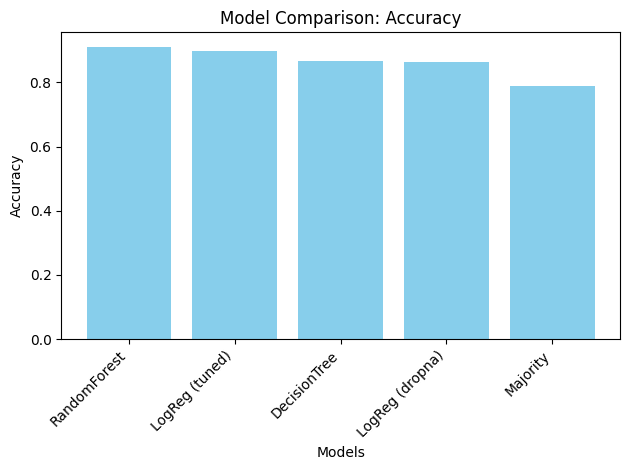

In [30]:
import matplotlib.pyplot as plt

# Model names
models = ["RandomForest", "LogReg (tuned)", "DecisionTree", "LogReg (dropna)", "Majority"]
accuracies = [0.9103, 0.897436, 0.865385, 0.862319, 0.788462]

# Plotting the bar chart
plt.bar(models, accuracies, color='skyblue')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Comparison: Accuracy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


'/content/drive/MyDrive/STATS201_project/figures/week4_model_comparison.png'

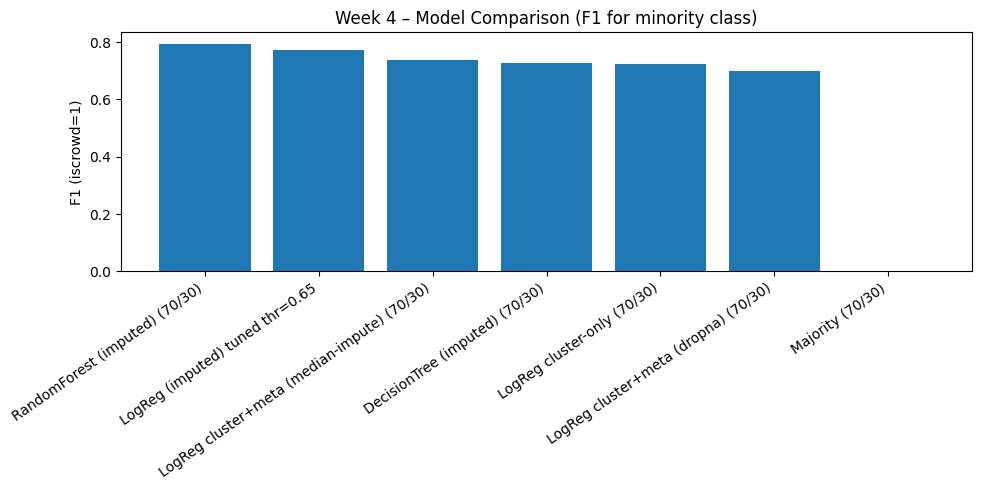

In [31]:
f1_col = "f1_1" if "f1_1" in results_df.columns else "f1_1"

plot_df = results_df.sort_values(f1_col, ascending=False).copy()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df[f1_col])
plt.xticks(rotation=35, ha="right")
plt.ylabel("F1 (iscrowd=1)")
plt.title("Week 4 – Model Comparison (F1 for minority class)")
plt.tight_layout()

# save to your Drive repo folder (edit this path to where your repo folder is)
FIG_DIR = "/content/drive/MyDrive/STATS201_project/figures"
os.makedirs(FIG_DIR, exist_ok=True)
fig_path = os.path.join(FIG_DIR, "week4_model_comparison.png")
plt.savefig(fig_path, dpi=200)
fig_path